# Genfit — B⁺ → π⁺π⁺π⁻: um toy independente por fit

Mesmo modelo isobárico do teste 01, com **uma nova amostra e um novo start para cada ajuste**. Apenas os dez coeficientes cartesianos livres são ajustados; ρ(770) é a referência fixa. Sem CP, eficiência ou fundo.

Execute em ordem com o ambiente do projeto. Eventos, número de fits e dispersão dos starts são configuráveis. As sementes de cada toy e os starts são registrados para reprodução. Um fit por toy permite estudar o procedimento completo, incluindo a possibilidade de mínimos locais; não garante encontrar o melhor mínimo de cada amostra.

In [1]:
from pathlib import Path
import sys

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/dalitzplotfitter').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Abra o notebook dentro do repositório DalitzPlotFitter.')
sys.path.insert(0, str(ROOT / 'src'))
from IPython.display import display
from time import perf_counter
import numpy as np
import pandas as pd
import jax.numpy as jnp
import matplotlib.pyplot as plt

from dataclasses import dataclass

from dalitzplotfitter import (
    DecayChannel,
    DecayModel,
    FitSession,
    GounarisSakurai,
    Parameter,
    RealImag,
    RelativisticBreitWigner,
    Resonance,
    enable_x64,
    generate_signal_toy,
)

enable_x64()

SEED = 20260905
N_EVENTS = 100_000
TOY_METHOD = "accept-reject"
NORMALIZATION_METHOD = "gauss-legendre"

channel = DecayChannel("B+", ("pi+", "pi+", "pi-"))
M_PI = float(channel.daughter_masses[0])

print("Toy size:", N_EVENTS)
print("Toy method:", TOY_METHOD)
print("Normalization:", NORMALIZATION_METHOD)

N_FITS = 100
START_SEED = SEED + 1
START_SIGMA = 0.30  # desvio absoluto de x e y em torno da verdade
NCALL = 20_000
STRATEGY = 2
TOLERANCE = 1e-4
assert N_EVENTS > 0 and N_FITS >= 2 and START_SIGMA > 0

Toy size: 100000
Toy method: accept-reject
Normalization: gauss-legendre


## Modelo gerador
Coeficientes e dinâmica reutilizados do estudo isobárico de fechamento existente. As duas partículas π⁺ são tratadas pelo modelo do canal.

In [2]:
TRUTH_COEFFICIENTS = {
    "rho770":    dict(x= 1.000, y= 0.000),
    "omega782":  dict(x= 0.091, y=-0.007),
    "f2_1270":   dict(x= 0.291, y= 0.204),
    "rho1450":   dict(x=-0.223, y= 0.191),
    "rho3_1690": dict(x= 0.073, y=-0.045),
    "sigma":     dict(x=-0.485, y= 0.284),
}

def truth_coefficient(name):
    p = TRUTH_COEFFICIENTS[name]
    return RealImag(p["x"], p["y"])


@dataclass(frozen=True)
class PaperSigmaPole:
    # LHCb Eq. (16): A_sigma(m) = 1 / (s_sigma - m^2)
    def __call__(self, mass, context):
        m = jnp.asarray(mass)
        pole = jnp.asarray(context.pole_mass) - 1j * jnp.asarray(context.pole_width)
        s_sigma = pole**2
        return 1.0 / (s_sigma - m**2)


def isobar_components(coefficient_factory):
    return [
        Resonance(
            "rho770", (0, 2), coefficient_factory("rho770"),
            mass=0.7708, width=0.1534, spin=1,
            lineshape=GounarisSakurai(),
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "omega782", (0, 2), coefficient_factory("omega782"),
            mass=0.78265, width=0.00849, spin=1,
            lineshape=RelativisticBreitWigner(),
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "f2_1270", (0, 2), coefficient_factory("f2_1270"),
            mass=1.2755, width=0.1867, spin=2,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "rho1450", (0, 2), coefficient_factory("rho1450"),
            mass=1.465, width=0.400, spin=1,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "rho3_1690", (0, 2), coefficient_factory("rho3_1690"),
            mass=1.6888, width=0.161, spin=3,
            resonance_radius=4.0, parent_radius=4.0,
        ),
        Resonance(
            "sigma", (0, 2), coefficient_factory("sigma"),
            mass=0.563, width=0.350, spin=0,
            lineshape=PaperSigmaPole(),
            resonance_radius=4.0, parent_radius=4.0,
        ),
    ]


generator = DecayModel(
    channel,
    isobar_components(truth_coefficient),
    normalize_components=True,
    normalization_method=NORMALIZATION_METHOD,
)

print("Generator normalization points:", generator.normalization_sample.size)

INFO DalitzPlotFitter normalization: narrow resonance band(s) detected (m13: m0=0.782650 GeV, Gamma=8.490 MeV; m23: m0=0.782650 GeV, Gamma=8.490 MeV); using adaptive Gauss-Legendre normalization.
Generator normalization points: 2080469


## Sementes independentes
Cada toy usa uma semente distinta. O gerador e a integração de normalização são compartilhados; os eventos são gerados novamente dentro do loop. As amostras não são acumuladas em memória.

In [3]:
toy_seeds = [int(s.generate_state(1, dtype=np.uint64)[0])
             for s in np.random.SeedSequence(SEED).spawn(N_FITS)]
assert len(set(toy_seeds)) == N_FITS
print('Primeiras sementes:', toy_seeds[:5])

Primeiras sementes: [5734163613718072789, 10843568836493112964, 5360109053914373194, 9040270409388520618, 6838429578534984449]


## Modelo de ajuste
Somente os dez coeficientes cartesianos não referenciais são livres.

In [4]:
def floating_coefficient(name):
    truth = TRUTH_COEFFICIENTS[name]
    reference = name == "rho770"
    return RealImag(
        Parameter.coefficient(
            f"{name}.x",
            truth["x"],
            owner=name,
            fixed=reference,
            step=0.01,
        ),
        Parameter.coefficient(
            f"{name}.y",
            truth["y"],
            owner=name,
            fixed=reference,
            step=0.01,
        ),
    )


fit_model = DecayModel(
    channel,
    isobar_components(floating_coefficient),
    normalize_components=True,
    normalization_method=NORMALIZATION_METHOD,
)


print('Parâmetros livres:', sum(not p.fixed for p in fit_model.parameters))

Parâmetros livres: 10


## Starts e logs
Cada start é sorteado em torno da verdade, sem usar o resultado anterior. Cada execução cria `genfit/logs/independent_<data>_<id>/`, com logs individuais, configuração, sementes, starts e CSVs atualizados após cada ajuste. A semente e o modelo permitem regenerar um toy no mesmo ambiente; os eventos não são salvos em disco.

In [5]:
free_parameters = tuple(p for p in fit_model.parameters if not p.fixed)
truth_values = {p.name: float(p.value) for p in fit_model.parameters}
rng = np.random.default_rng(START_SEED)
starts = [
    {p.name: float(truth_values[p.name] + rng.normal(0, START_SIGMA))
     for p in free_parameters}
    for _ in range(N_FITS)
]
assert len({tuple(s.items()) for s in starts}) == N_FITS
starts_table = pd.DataFrame(starts).rename_axis('fit_id')
starts_table.insert(0, 'toy_seed', toy_seeds)
display(starts_table)

,toy_seed,omega782.x,omega782.y,f2_1270.x,f2_1270.y,rho1450.x,rho1450.y,rho3_1690.x,rho3_1690.y,sigma.x,sigma.y
fit_id,,,,,,,,,,,
0,5734163613718072789,0.241749,-0.122138,0.534609,-0.070515,-0.236086,0.449812,0.371532,0.382253,-0.534465,0.428955
1,10843568836493112964,-0.312971,-0.021339,0.111989,-0.056520,-0.366324,0.298341,0.379612,0.642962,-0.719463,0.394515
2,5360109053914373194,0.315112,0.261491,0.856246,0.437698,0.347994,0.414155,0.063495,-0.087406,-0.453773,-0.007044
3,9040270409388520618,0.115948,-0.249547,0.002909,-0.058741,-0.169407,0.140649,-0.079130,-0.285135,-0.152160,0.337011
4,6838429578534984449,-0.059551,-0.092367,0.595006,0.271837,0.550472,0.082273,-0.278738,0.333257,-0.178080,0.667313
...,...,...,...,...,...,...,...,...,...,...,...
95,12038175148865763224,-0.237473,-0.285244,0.257844,0.062641,-0.277427,0.382867,0.432123,-0.270427,-0.510126,0.078179
96,16261880647681849399,-0.032596,-0.316234,0.316967,0.087974,-0.519850,0.243562,0.440057,0.254213,-0.580708,-0.045632
97,18105346768116085406,0.285832,0.278280,0.113078,0.229741,0.168671,-0.032562,-0.300615,0.198428,-0.062185,0.288133


In [6]:
from contextlib import redirect_stdout, redirect_stderr
from datetime import datetime, timezone
import json
import traceback
from uuid import uuid4

# Uma pasta nova a cada execução desta célula, sem sobrescrever logs anteriores.
run_id = 'independent_' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S_%fZ') + '_' + uuid4().hex[:8]
log_dir = ROOT / 'genfit' / 'logs' / run_id
log_dir.mkdir(parents=True, exist_ok=False)
config = dict(seed=SEED, start_seed=START_SEED, n_events=N_EVENTS,
              n_fits=N_FITS, start_sigma=START_SIGMA, ncall=NCALL,
              strategy=STRATEGY, tolerance=TOLERANCE,
              toy_seeds=toy_seeds, toy_method=TOY_METHOD,
              normalization_method=NORMALIZATION_METHOD,
              truth_values=truth_values, starts=starts)
(log_dir / 'config.json').write_text(
    json.dumps(config, indent=2, ensure_ascii=False), encoding='utf-8')
starts_table.to_csv(log_dir / 'starts.csv')
print(f'Logs desta execução: {log_dir}')

results = []
summary_rows = []
parameter_rows = []
for fit_id, start_values in enumerate(starts):
    toy_seed = toy_seeds[fit_id]
    truth_nll = np.nan
    generation_seconds = np.nan
    t0 = perf_counter()
    log_path = log_dir / f'fit_{fit_id:03d}.log'
    with log_path.open('w', encoding='utf-8', buffering=1) as log:
        with redirect_stdout(log), redirect_stderr(log):
            print(f'fit_id={fit_id}, toy_seed={toy_seed}')
            print('start_values=' + json.dumps(start_values, sort_keys=True))
            print('Configuração completa em config.json')
            try:
                generation_start = perf_counter()
                toy = generate_signal_toy(
                    generator, N_EVENTS, seed=toy_seed, method=TOY_METHOD,
                    include_momenta=False,
                )
                assert toy.size == N_EVENTS
                generation_seconds = perf_counter() - generation_start
                session = FitSession(fit_model, toy)
                truth_nll = float(session.objective(truth_values))
                print(f'n_events={toy.size}, truth_nll={truth_nll:.9f}')
                result = session.fit(
                    start_values=dict(start_values), simplex=False, strategy=STRATEGY,
                    hesse=True, tolerance=TOLERANCE, ncall=NCALL, verbose=2,
                )
                print(result)
                session.print_result(result)
                failure = None
            except Exception as exc:
                traceback.print_exc()
                result = None
                failure = repr(exc)
            finally:
                print(f'elapsed_seconds={perf_counter()-t0:.6f}')
    if result is None:
        results.append(None)
        summary_rows.append(dict(fit_id=fit_id, toy_seed=toy_seed, valid=False, nll=np.nan,
                                 truth_nll=truth_nll, nll_minus_truth=np.nan,
                                 generation_seconds=generation_seconds,
                                 seconds=perf_counter()-t0, exception=failure,
                                 log_file=str(log_path)))
        pd.DataFrame(summary_rows).to_csv(log_dir / 'summary.csv', index=False)
        print(f'Fit {fit_id}: falhou: {failure}; log: {log_path.name}', flush=True)
        continue
    results.append(result)
    summary_rows.append(dict(
        fit_id=fit_id, toy_seed=toy_seed, valid=bool(result.valid), nll=float(result.fval),
        truth_nll=truth_nll, nll_minus_truth=float(result.fval)-truth_nll,
        generation_seconds=generation_seconds,
        edm=float(result.fmin.edm), nfcn=int(result.nfcn),
        accurate_covariance=bool(result.fmin.has_accurate_covar),
        call_limit=bool(result.fmin.has_reached_call_limit),
        seconds=perf_counter()-t0, exception='', log_file=str(log_path),
    ))
    values = session.result_values(result)
    for p in session.parameters:
        error = 0.0 if p.fixed else float(result.errors[p.name])
        parameter_rows.append(dict(
            fit_id=fit_id, parameter=p.name, fixed=p.fixed,
            truth=truth_values[p.name], start=start_values.get(p.name, p.value),
            value=values[p.name], error=error,
            pull=(values[p.name]-truth_values[p.name])/error if error > 0 else np.nan,
        ))
    pd.DataFrame(summary_rows).to_csv(log_dir / 'summary.csv', index=False)
    pd.DataFrame(parameter_rows).to_csv(log_dir / 'parameters.csv', index=False)
    print(f'Fit {fit_id}: valid={result.valid}, NLL={result.fval:.6f}, '
          f'EDM={result.fmin.edm:.2e}', flush=True)

summary = pd.DataFrame(summary_rows).set_index('fit_id')
parameters = pd.DataFrame(parameter_rows)
valid = summary['valid'] & np.isfinite(summary['nll'])
summary.to_csv(log_dir / 'summary.csv')
parameters.to_csv(log_dir / 'parameters.csv', index=False)
display(summary)
print(f'Ajustes válidos: {valid.sum()}/{N_FITS}')
print('Cada nova sessão pode incluir compilação JAX; tempos incluem geração e ajuste.')

Logs desta execução: /home/juan-leite/Work/DalitzPlotFitter/genfit/logs/independent_20260909T214244_878666Z_65e695bd
Fit 0: valid=True, NLL=421650.748392, EDM=9.52e-13
Fit 1: valid=True, NLL=421901.956513, EDM=2.59e-09
Fit 2: valid=True, NLL=420699.783973, EDM=3.20e-09
Fit 3: valid=True, NLL=421726.317855, EDM=4.36e-08
Fit 4: valid=True, NLL=420908.608571, EDM=3.34e-09
Fit 5: valid=True, NLL=421096.334417, EDM=3.30e-09
Fit 6: valid=True, NLL=420638.468017, EDM=1.70e-10
Fit 7: valid=True, NLL=421789.437123, EDM=1.75e-11
Fit 8: valid=True, NLL=421516.576686, EDM=2.33e-08
Fit 9: valid=True, NLL=420965.754070, EDM=3.81e-10
Fit 10: valid=True, NLL=420917.639847, EDM=1.63e-08
Fit 11: valid=True, NLL=421503.298368, EDM=4.09e-08
Fit 12: valid=True, NLL=421178.582748, EDM=1.65e-09
Fit 13: valid=True, NLL=422068.046241, EDM=8.75e-09
Fit 14: valid=True, NLL=422047.886131, EDM=1.30e-08
Fit 15: valid=True, NLL=421322.972252, EDM=7.50e-09
Fit 16: valid=True, NLL=421225.067281, EDM=4.04e-09
Fit 17: v

,toy_seed,valid,nll,truth_nll,nll_minus_truth,generation_seconds,edm,nfcn,accurate_covariance,call_limit,seconds,exception,log_file
fit_id,,,,,,,,,,,,,
0,5734163613718072789,True,421650.748392,421655.069136,-4.320744,11.629805,9.522267e-13,606.0,True,False,19.610792,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...
1,10843568836493112964,True,421901.956513,420759.603838,1142.352675,4.269790,2.590508e-09,618.0,True,False,5.613319,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...
2,5360109053914373194,True,420699.783973,420702.988122,-3.204149,3.703589,3.197965e-09,577.0,True,False,5.018828,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...
3,9040270409388520618,True,421726.317855,421729.650066,-3.332212,4.108181,4.355323e-08,626.0,True,False,5.514162,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...
4,6838429578534984449,True,420908.608571,420917.018700,-8.410129,3.879755,3.335831e-09,590.0,True,False,5.148611,,/home/juan-leite/Work/DalitzPlotFitter/genfit/...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,12038175148865763224,False,NaN,420928.701927,NaN,3.902712,NaN,NaN,NaN,NaN,4.538272,"JaxRuntimeError(""RESOURCE_EXHAUSTED: [0] Faile...",/home/juan-leite/Work/DalitzPlotFitter/genfit/...
96,16261880647681849399,False,NaN,421563.543949,NaN,3.812729,NaN,NaN,NaN,NaN,4.461621,"JaxRuntimeError(""RESOURCE_EXHAUSTED: [0] Faile...",/home/juan-leite/Work/DalitzPlotFitter/genfit/...
97,18105346768116085406,False,NaN,421123.451966,NaN,4.303578,NaN,NaN,NaN,NaN,4.943457,"JaxRuntimeError(""RESOURCE_EXHAUSTED: [0] Faile...",/home/juan-leite/Work/DalitzPlotFitter/genfit/...


Ajustes válidos: 79/100
Cada nova sessão pode incluir compilação JAX; tempos incluem geração e ajuste.


## Diagnósticos do ensemble
Não comparamos NLL absoluta entre amostras distintas. `nll_minus_truth` compara o fit à verdade **no próprio toy**: um valor positivo relevante revela que o ajuste ficou pior que um ponto conhecido. Um valor negativo não prova que o mínimo global foi encontrado.

Os pulls são `(valor − verdade) / erro HESSE`. Mostramos apenas fits válidos com erros finitos e positivos, informando a seleção. Média próxima de zero e largura próxima de um são referências para um ensemble suficientemente grande; dez toys servem somente como teste rápido. Mínimos locais podem produzir caudas, e a seleção por validade também pode afetar a distribuição.

,n,mean_pull,std_pull,mean_value,mean_error
parameter,,,,,
f2_1270.x,79,-0.836293,3.163003,0.288509,0.003440
f2_1270.y,79,-1.046020,3.420152,0.200872,0.003364
omega782.x,79,-17.854700,62.335432,0.046126,0.003220
omega782.y,79,-3.998412,12.962267,-0.017961,0.003625
rho1450.x,79,0.529245,2.148483,-0.220846,0.004581
rho1450.y,79,-0.861983,2.829462,0.188378,0.003509
rho3_1690.x,79,-0.220211,1.118924,0.072424,0.002851
rho3_1690.y,79,0.127655,1.089684,-0.044602,0.003561
sigma.x,79,2.326673,7.683396,-0.478487,0.003276


Fits válidos selecionados: 79/100
Fits com NLL acima da verdade por mais de 0.001: [1, 20, 35, 43, 50, 56]


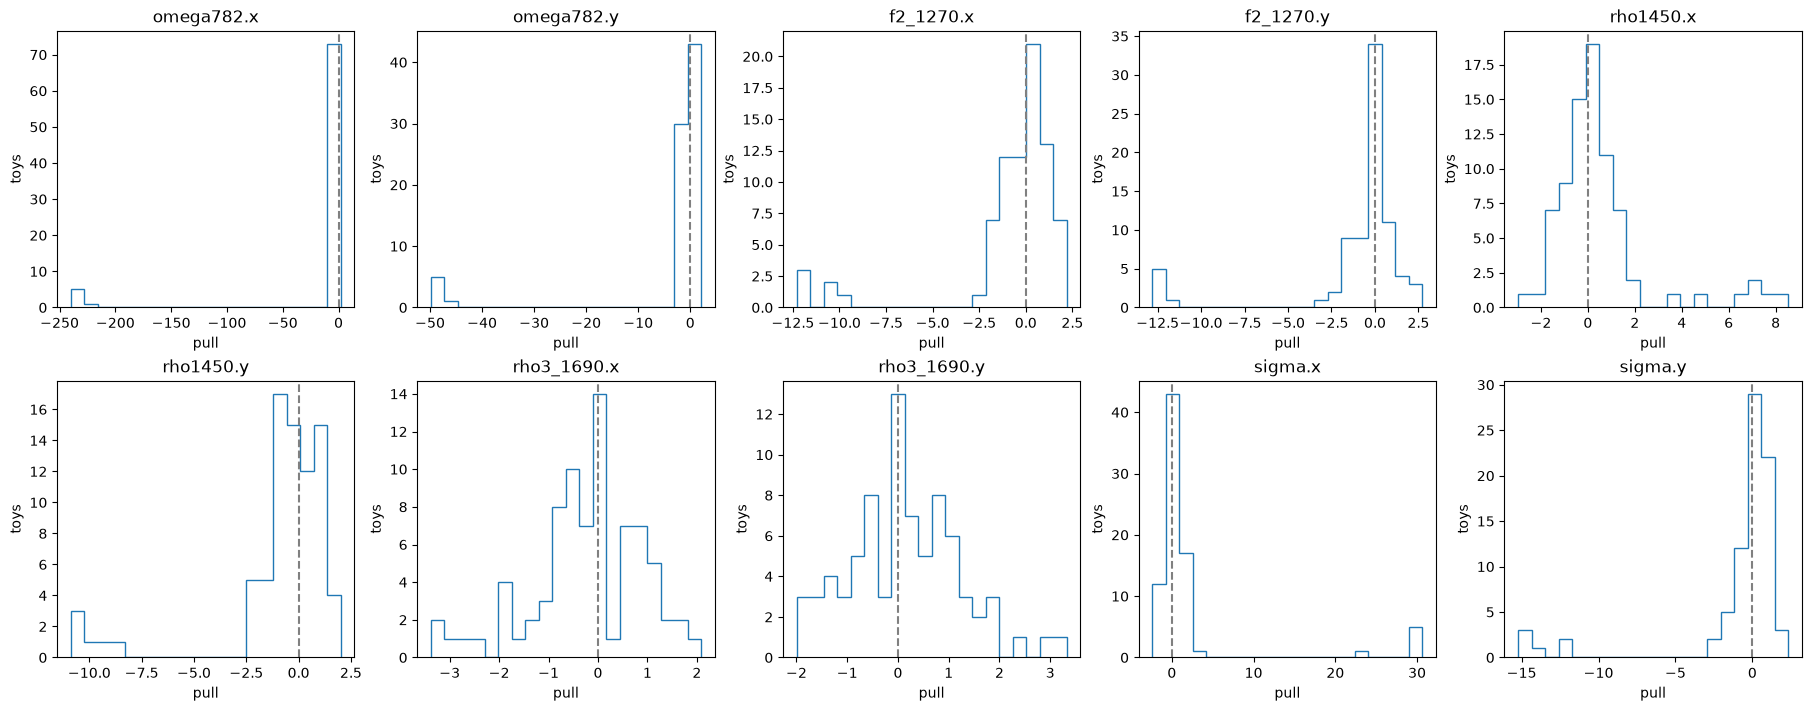

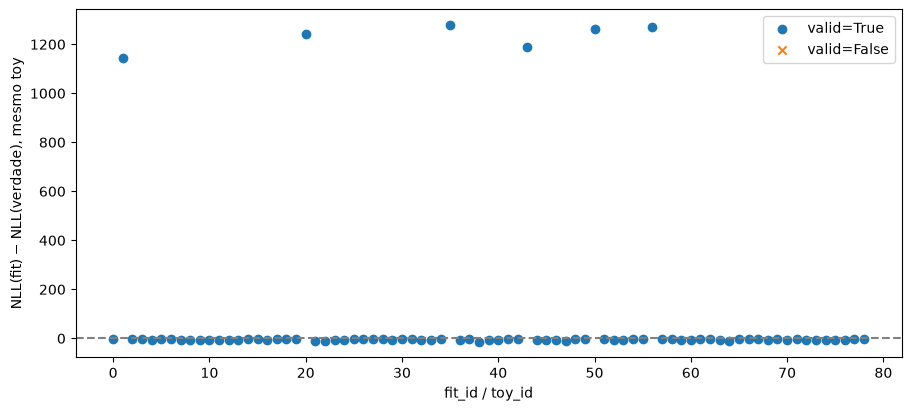

In [7]:
if parameters.empty:
    print('Nenhum resultado disponível; consulte os logs de exceção.')
else:
    valid_ids = summary.index[valid]
    selected = parameters.loc[
        parameters.fit_id.isin(valid_ids) & ~parameters.fixed
        & np.isfinite(parameters.pull) & (parameters.error > 0)
    ]
    pull_summary = selected.groupby('parameter').agg(
        n=('pull', 'size'), mean_pull=('pull', 'mean'),
        std_pull=('pull', 'std'), mean_value=('value', 'mean'),
        mean_error=('error', 'mean'),
    )
    display(pull_summary)
    pull_summary.to_csv(log_dir / 'pull_summary.csv')
    print(f'Fits válidos selecionados: {len(valid_ids)}/{N_FITS}')
    print('Fits com NLL acima da verdade por mais de 0.001:',
          summary.index[summary.nll_minus_truth > 1e-3].tolist())
    fig, axes = plt.subplots(2, 5, figsize=(18, 7), constrained_layout=True)
    for ax, p in zip(axes.flat, free_parameters):
        values = selected.loc[selected.parameter == p.name, 'pull']
        ax.hist(values, bins=min(20, max(5, len(values))), histtype='step')
        ax.axvline(0, color='grey', linestyle='--')
        ax.set(title=p.name, xlabel='pull', ylabel='toys')
    plt.show()
    fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
    for state, marker in [(True, 'o'), (False, 'x')]:
        rows = summary.loc[summary.valid == state]
        ax.scatter(rows.index, rows.nll_minus_truth, marker=marker,
                   label=f'valid={state}')
    ax.axhline(0, color='grey', linestyle='--')
    ax.set(xlabel='fit_id / toy_id', ylabel='NLL(fit) − NLL(verdade), mesmo toy')
    ax.legend()
    plt.show()

## Como interpretar
- Verifique validade, EDM, covariância, exceções e limite de chamadas em `summary`.
- Consulte `parameters` e as distribuições de pulls para avaliar recuperação dos coeficientes.
- Mínimos locais podem existir mesmo com `valid=True`. Reajustar um toy suspeito exige sua semente registrada e novos starts, mantendo essa amostra fixa.
- Não escolha um “melhor toy” pela menor NLL entre amostras diferentes.
- Aumente `N_FITS` para um estudo estatístico; a geração e uma nova sessão por toy tornam este teste mais caro que o teste 01.